In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "Data/final_customer_support.csv"
)

df.shape

(200000, 36)

In [3]:
df.columns.tolist()

['ticket_id',
 'customer_name',
 'customer_email',
 'product',
 'category',
 'issue_description',
 'resolution_notes',
 'priority',
 'status',
 'channel',
 'region',
 'customer_age',
 'customer_gender',
 'subscription_type',
 'customer_tenure_months',
 'previous_tickets',
 'customer_satisfaction_score',
 'first_response_time_hours',
 'resolution_time_hours',
 'ticket_created_date',
 'ticket_resolved_date',
 'escalated',
 'sla_breached',
 'operating_system',
 'browser',
 'payment_method',
 'language',
 'preferred_contact_time',
 'issue_complexity_score',
 'customer_segment',
 'issue_length',
 'resolution_length',
 'ticket_duration_days',
 'created_year',
 'created_month',
 'created_dayofweek']

In [4]:
df["resolution_time_hours"].describe()

count    200000.000000
mean        120.539718
std          68.969143
min           1.000000
25%          60.810000
50%         120.450000
75%         180.260000
max         240.000000
Name: resolution_time_hours, dtype: float64

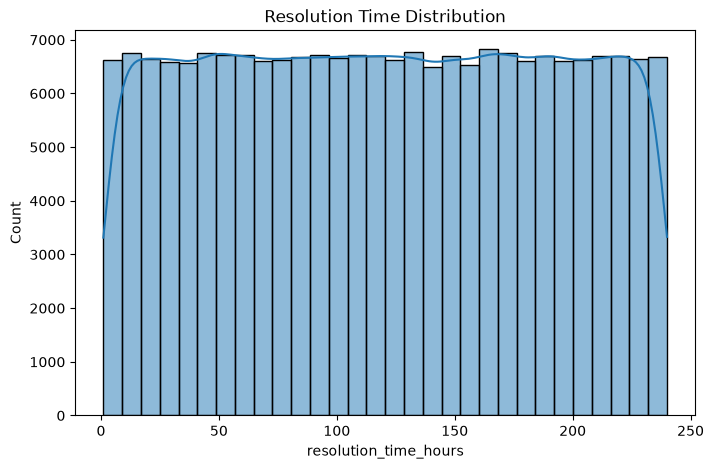

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["resolution_time_hours"],
    bins=30,
    kde=True
)

plt.title("Resolution Time Distribution")

plt.show()

In [6]:
features = [
    "customer_age",
    "customer_tenure_months",
    "previous_tickets",
    "customer_satisfaction_score",
    "first_response_time_hours",
    "issue_complexity_score",
    "issue_length",
    "resolution_length",
    "ticket_duration_days"
]

X = df[features]

y = df["resolution_time_hours"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(160000, 9)
(40000, 9)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("MAE :", round(mae_lr,2))
print("RMSE:", round(rmse_lr,2))
print("R²  :", round(r2_lr,4))

Linear Regression Results
MAE : 59.8
RMSE: 68.99
R²  : -0.0001


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("MAE :", round(mae_rf,2))
print("RMSE:", round(rmse_rf,2))
print("R²  :", round(r2_rf,4))

Random Forest Results
MAE : 60.28
RMSE: 69.82
R²  : -0.0242


In [11]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        mae_lr,
        mae_rf
    ],

    "RMSE":[
        rmse_lr,
        rmse_rf
    ],

    "R2":[
        r2_lr,
        r2_rf
    ]

})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,59.795495,68.991581,-0.000068
1,Random Forest,60.277633,69.817644,-0.024160


In [12]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,first_response_time_hours,0.221978
0,customer_age,0.144772
1,customer_tenure_months,0.139870
2,previous_tickets,0.109192
8,ticket_duration_days,0.097637
5,issue_complexity_score,0.083915
7,resolution_length,0.078527
6,issue_length,0.071609
3,customer_satisfaction_score,0.052500


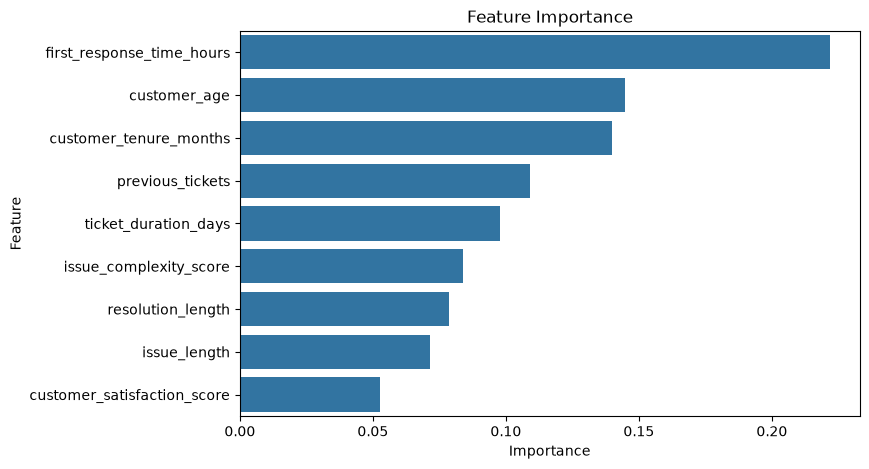

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

In [14]:
import joblib

joblib.dump(
    rf,
    "models/resolution_time_rf.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
